Training Path: e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Training
Testing Path: e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Testing
Total Samples: (7023, 224, 224, 3)


MemoryError: Unable to allocate 5.67 GiB for an array with shape (5056, 224, 224, 3) and data type float64

Loading Training data...


FileNotFoundError: [WinError 3] The system cannot find the path specified: './brain_tumor_mri_dataset\\Training\\Glioma'

Loading Training data...


FileNotFoundError: [WinError 3] The system cannot find the path specified: './DeepLearning_module/notebook/Img_data/brain_tumor_mri_dataset\\Training\\glioma'

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# ✅ Use absolute path based on your screenshot
base_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\Img_data\brain_tumor_mri_dataset"
train_dir = os.path.join(base_dir, "Training")
test_dir = os.path.join(base_dir, "Testing")

labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
img_size = 128

def load_data(directory):
    data = []
    target = []
    for label in labels:
        path = os.path.join(directory, label)  # folder name directly
        if not os.path.exists(path):
            print(f"❌ Missing folder: {path}")
            continue
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img = load_img(img_path, target_size=(img_size, img_size))
                img_array = img_to_array(img)
                data.append(img_array)
                target.append(class_num)
            except Exception as e:
                print("⚠️ Error loading:", img_path, e)
    return np.array(data), np.array(target)

# Load training and testing data
print("Loading Training data...")
X_train, y_train = load_data(train_dir)
print("Loading Testing data...")
X_test, y_test = load_data(test_dir)

print("✅ Training samples:", X_train.shape)
print("✅ Testing samples:", X_test.shape)


Loading Training data...
Loading Testing data...
✅ Training samples: (5712, 128, 128, 3)
✅ Testing samples: (1311, 128, 128, 3)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


Epoch 1/10


143/143 [==============================] - 276s 2s/step - loss: 1.5935 - accuracy: 0.2566 - val_loss: 1.3586 - val_accuracy: 0.3821
Epoch 2/10
143/143 [==============================] - 266s 2s/step - loss: 1.4649 - accuracy: 0.2925 - val_loss: 1.3335 - val_accuracy: 0.3856
Epoch 3/10
143/143 [==============================] - 262s 2s/step - loss: 1.4006 - accuracy: 0.3268 - val_loss: 1.3109 - val_accuracy: 0.4093
Epoch 4/10
143/143 [==============================] - 267s 2s/step - loss: 1.3346 - accuracy: 0.3599 - val_loss: 1.2979 - val_accuracy: 0.3935
Epoch 5/10
143/143 [==============================] - 262s 2s/step - loss: 1.2990 - accuracy: 0.3737 - val_loss: 1.2840 - val_accuracy: 0.3996
Epoch 6/10
143/143 [==============================] - 274s 2s/step - loss: 1.2595 - accuracy: 0.3898 - val_loss: 1.2794 - val_accuracy: 0.3883
Epoch 7/10
1

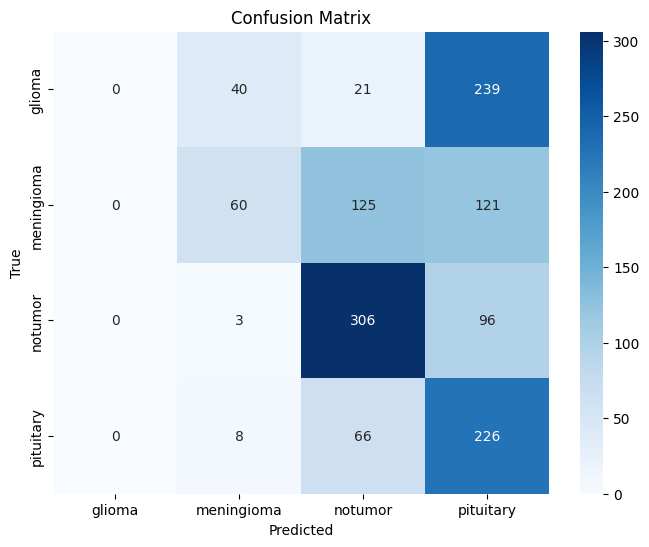

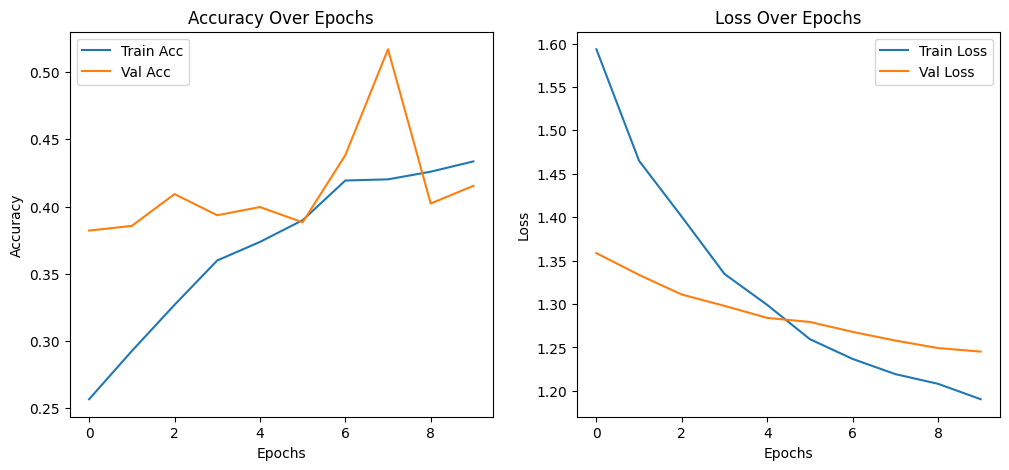

In [16]:
import os
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ===============================
# Data Preprocessing
# ===============================

# ✅ Correct dataset paths for your system
train_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Training"
test_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Testing"


img_height, img_width = 224, 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2   # 20% of training data as validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=1,
    class_mode="categorical",
    shuffle=False
)

# ===============================
# Model Building (ResNet50 Transfer Learning)
# ===============================

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(img_height, img_width, 3))

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)  # Regularization
predictions = Dense(len(train_generator.class_indices), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# ===============================
# Training
# ===============================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# ===============================
# Evaluation
# ===============================

loss, acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {acc:.4f}")

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# ===============================
# Confusion Matrix
# ===============================

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# Training History Plot
# ===============================

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Over Epochs")

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Over Epochs")

plt.show()


Training path: e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Training
Testing path: e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Testing
Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.

--- Starting Phase 1: Feature Extraction (Frozen Base) ---
Epoch 1/10
143/143 [==============================] - 272s 2s/step - loss: 1.3512 - accuracy: 0.3599 - val_loss: 1.2469 - val_accuracy: 0.4443
Epoch 2/10
143/143 [==============================] - 268s 2s/step - loss: 1.1763 - accuracy: 0.4345 - val_loss: 1.2566 - val_accuracy: 0.3786
Epoch 3/10
143/143 [==============================] - 265s 2s/step - loss: 1.1347 - accuracy: 0.4502 - val_loss: 1.2186 - val_accuracy: 0.4628
Epoch 4/10
143/143 [==============================] - 263s 2s/step - loss: 1.1031 - accuracy: 0.4907 - val_loss: 1.1857 - val_accuracy: 0.5118
Epoch 5/10
143/143 [==========

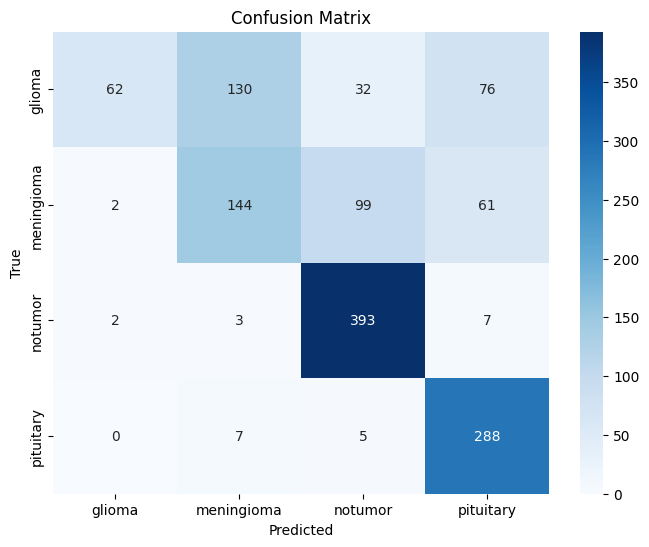

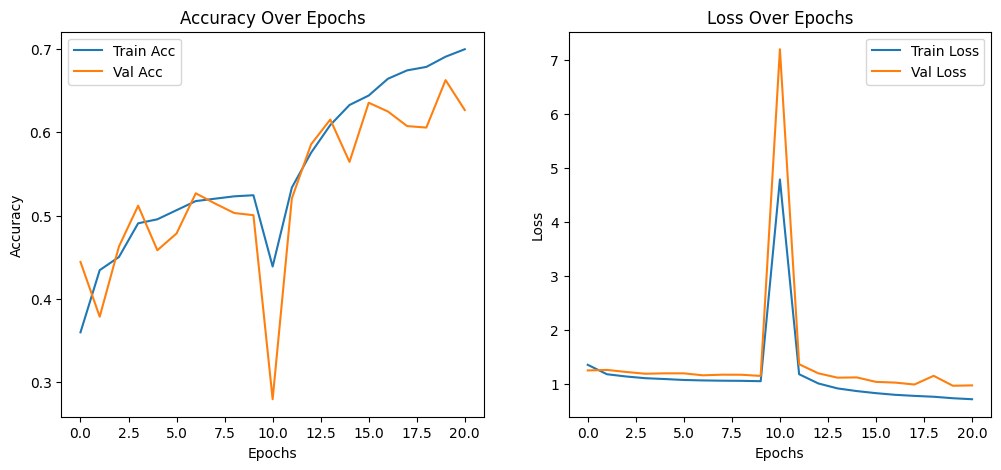

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ===============================
# 1. Configuration and Paths
# ===============================

# Use your dataset's name and class count
DATASET_NAME = 'brain_tumor_mri_dataset'
NUM_CLASSES = 4
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# Pathing (Adjust if your notebook is not at the project root)
# Assumes the notebook is at HealthCareProject/notebook/
# project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
# base_dir = os.path.join(project_root, 'DeepLearning_module', 'Img_data', DATASET_NAME)
# train_dir = os.path.join(base_dir, 'Training')
# test_dir = os.path.join(base_dir, 'Testing')
train_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Training"
test_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Testing"

print(f"Training path: {train_dir}")
print(f"Testing path: {test_dir}")

# ===============================
# 2. Data Preprocessing & Generation
# ===============================

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, # Batch size of 1 for correct prediction order
    class_mode="categorical",
    shuffle=False
)

# ===============================
# 3. Model Building (ResNet50 Transfer Learning)
# ===============================

# Load ResNet50 base model with pre-trained weights
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the base model layers for the first training phase
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

# ===============================
# 4. Phase 1: Training (Feature Extraction)
# ===============================

print("\n--- Starting Phase 1: Feature Extraction (Frozen Base) ---")

model.compile(optimizer=Adam(learning_rate=0.001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10 # Use fewer epochs for this phase
)

# ===============================
# 5. Phase 2: Fine-Tuning
# ===============================

print("\n--- Starting Phase 2: Fine-Tuning ---")

# Unfreeze the top layers of the base model
base_model.trainable = True

# We can freeze a portion of the layers to maintain pre-trained knowledge
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile the model with a very low learning rate
model.compile(optimizer=Adam(learning_rate=0.00001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train again for a few more epochs
history_fine_tune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20, # Run for more epochs to allow fine-tuning
    initial_epoch=history.epoch[-1] # Start from where the last training left off
)


# ===============================
# 6. Evaluation
# ===============================

print("\n--- Final Evaluation ---")
loss, acc = model.evaluate(test_generator, verbose=1)
print(f"Final Test Accuracy: {acc:.4f}")

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# ===============================
# 7. Visualization
# ===============================

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Training History Plot
plt.figure(figsize=(12,5))
combined_history_acc = history.history["accuracy"] + history_fine_tune.history["accuracy"]
combined_history_val_acc = history.history["val_accuracy"] + history_fine_tune.history["val_accuracy"]

plt.subplot(1,2,1)
plt.plot(combined_history_acc, label="Train Acc")
plt.plot(combined_history_val_acc, label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Over Epochs")

combined_history_loss = history.history["loss"] + history_fine_tune.history["loss"]
combined_history_val_loss = history.history["val_loss"] + history_fine_tune.history["val_loss"]

plt.subplot(1,2,2)
plt.plot(combined_history_loss, label="Train Loss")
plt.plot(combined_history_val_loss, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Over Epochs")

plt.show()